# A/B-тест геймификации на образовательной платформе

**Цель:** оценить влияние системы достижений за регулярное решение задач на Completion Rate и Retention (D7, D14).

**Гипотеза:** геймификация статистически значимо повышает конверсию в полное прохождение модуля и метрики удержания.

**Дизайн эксперимента:**
- Группа A — контроль (старый интерфейс)
- Группа B — тест (геймификация)
- Длительность: 3 недели (04.05.2026 – 24.05.2026)
- Метрики: D7/D14 Retention, Completion Rate, среднее число решённых ДЗ

## 0. Импорты и настройка отображения

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint, proportion_effectsize, confint_proportions_2indep
from statsmodels.stats.power import NormalIndPower
import matplotlib.pyplot as plt
from scipy.stats import norm, chi2
from scipy.optimize import brentq
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from scipy.stats import fisher_exact, chisquare
import warnings
import os 

warnings.filterwarnings('ignore')

# Настройка отображения графиков и формата чисел
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

# Настраиваем генератор случайных чисел для воспроизводимости
np.random.seed(42)

# Папка для графиков
FIGURES_PATH = 'figures/'
os.makedirs(FIGURES_PATH, exist_ok=True)

## 1. Подготовка данных

### 1.1 Datasets INFO

In [2]:
def print_dataset_info(df, name, head=5):
    print(f'============ {name} Datset ============')
    print('Dataset Shape:', df.shape)
    print('Columns:', df.columns.values)
    print('Number of unique users:', df['user_id'].nunique())
    print(f'Head (rows={head}) of Dataset:')
    print(df_groups.head(head)) 
    print(f'=======================================\n')
    
df_groups = pd.read_csv('ab_test_users_groups.csv')
df_events = pd.read_csv('ab_test_events.csv')

df_groups['signup_date'] = pd.to_datetime(df_groups['signup_date'])
df_events['timestamp'] = pd.to_datetime(df_events['timestamp'])

print_dataset_info(df_groups, "Groups")
print_dataset_info(df_events, "Events")

============ Groups Datset ============
Dataset Shape: (6008, 4)
Columns: ['user_id' 'group' 'signup_date' 'grade']
Number of unique users: 6000
Head (rows=5) of Dataset:
   user_id group signup_date  grade
0  U300000     B  2026-03-09      5
1  U300001     B  2025-09-07      9
2  U300002     B  2026-01-11      9
3  U300003     A  2025-06-07      5
4  U300004     B  2025-12-25     11

============ Events Datset ============
Dataset Shape: (179330, 3)
Columns: ['user_id' 'timestamp' 'event_type']
Number of unique users: 6000
Head (rows=5) of Dataset:
   user_id group signup_date  grade
0  U300000     B  2026-03-09      5
1  U300001     B  2025-09-07      9
2  U300002     B  2026-01-11      9
3  U300003     A  2025-06-07      5
4  U300004     B  2025-12-25     11



In [3]:
def print_ab_info(df):
    print(f'\n======================================')
    print('Dataset Shape:', df.shape)
    print('Number Unique user_id:', df['user_id'].nunique())

    info = (
        df.groupby('group')
        .agg(
            n_rows=('user_id', 'count'),
            n_users=('user_id', 'nunique')
        )
    )

    info['n_rows/n_users'] = info['n_rows'] / info['n_users']
    print(info)
    print(f'======================================\n')

    
print_ab_info(df_groups)
print('duplicates:', df_groups['user_id'].duplicated().sum())

if df_groups['user_id'].duplicated().any():
    print('\nДубликаты user_id:')
    print(
        df_groups[
            df_groups['user_id'].duplicated(keep=False)
        ]
        .sort_values('user_id')
    )

# Считаю необходимым удаление повторных вхождений юзеров чтобы не портить статистики в поиске ботов
df_groups = df_groups.drop_duplicates(
    subset='user_id',
    keep=False
)
print_ab_info(df_groups)

# Здесь же удалится и пересечение между A и B группами, если пересечение есть


Dataset Shape: (6008, 4)
Number Unique user_id: 6000
       n_rows  n_users  n_rows/n_users
group                                 
A        3005     3005          1.0000
B        3003     3003          1.0000

duplicates: 8

Дубликаты user_id:
      user_id group signup_date  grade
357   U300357     A  2026-03-19      9
6000  U300357     B  2026-03-19      9
460   U300460     B  2025-08-12      6
6001  U300460     A  2025-08-12      6
920   U300920     B  2025-04-09     10
6002  U300920     A  2025-04-09     10
1014  U301014     A  2026-03-28     10
6003  U301014     B  2026-03-28     10
1087  U301087     B  2025-06-27     10
6004  U301087     A  2025-06-27     10
1367  U301367     B  2025-09-03      8
6005  U301367     A  2025-09-03      8
1554  U301554     A  2025-09-25      9
6006  U301554     B  2025-09-25      9
5216  U305216     B  2025-07-17      9
6007  U305216     A  2025-07-17      9

Dataset Shape: (5992, 4)
Number Unique user_id: 5992
       n_rows  n_users  n_rows/n_users

In [4]:
# Объединяем данные с помощью left join по user_id
df = df_events.merge(
    df_groups,
    on='user_id',
    how='left'
)

print_ab_info(df)
print(df.head())


Dataset Shape: (179330, 6)
Number Unique user_id: 6000
       n_rows  n_users  n_rows/n_users
group                                 
A       82915     2997         27.6660
B       96198     2995         32.1195

   user_id           timestamp          event_type group signup_date   grade
0  U300281 2026-05-04 00:06:44  homework_completed     B  2025-08-01 11.0000
1  U300733 2026-05-04 00:19:56  homework_completed     B  2025-07-12  7.0000
2  U304499 2026-05-04 00:22:07               login     A  2025-10-26 11.0000
3  U304266 2026-05-04 00:23:42    homework_started     A  2025-12-30  9.0000
4  U304266 2026-05-04 00:23:42    homework_started     A  2025-12-30  9.0000


In [5]:
# grade поменялся на float, вероятно появился NaN

In [6]:
print('NaN в group:', df['group'].isna().sum())
missing_grade = df[df['group'].isna()]

print('Строк:', len(missing_grade))
print('Уникальных пользователей:', missing_grade['user_id'].nunique())

display(missing_grade.head())

NaN в group: 217
Строк: 217
Уникальных пользователей: 8


,user_id,timestamp,event_type,group,signup_date,grade
797,U300357,2026-05-04 15:33:00,login,NaN,NaT,NaN
847,U300357,2026-05-04 15:36:00,homework_started,NaN,NaT,NaN
1542,U301014,2026-05-04 16:09:00,login,NaN,NaT,NaN
1679,U301014,2026-05-04 16:16:00,homework_started,NaN,NaT,NaN
2724,U300460,2026-05-04 17:01:00,login,NaN,NaT,NaN


In [7]:
df = df.dropna(subset=['group']).copy()
print('NaN в group:', df['group'].isna().sum())
print('NaN в grade:', df['grade'].isna().sum())

NaN в group: 0
NaN в grade: 0


### 1.2 Поиск выбросов, аномалий и ботов


=== events_count ===
mean: 29.8920
std:  34.0239
skew: 21.0494
min: 6.0000
max: 842.0000

Quantiles:
 0.0010     9.0000
0.0100    14.0000
0.0500    18.0000
0.1000    20.0000
0.2500    24.0000
0.3500    26.0000
0.5000    28.0000
0.6000    30.0000
0.7000    32.0000
0.7500    33.0000
0.8000    34.0000
0.9500    40.0000
0.9900    45.0900
0.9990   770.0090
Name: events_count, dtype: float64


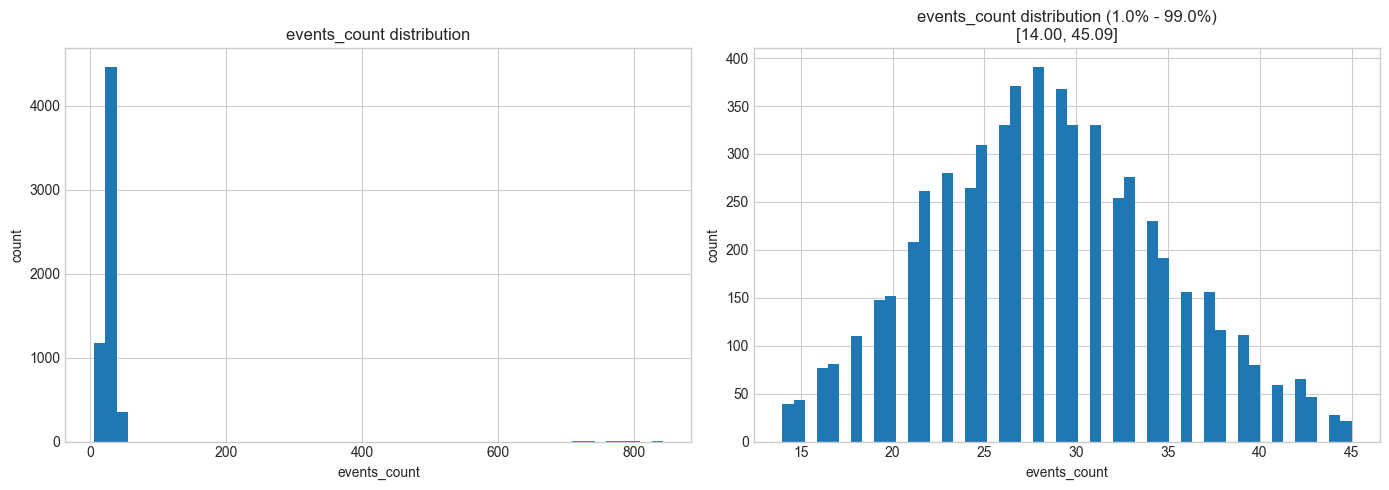

In [8]:
def show_distribution(
    data,
    feature,
    quantiles,
    quantile_range=(0.01, 0.99),
    bins=50,
    figsize=(14, 5)
):
    x = data[feature].dropna()

    quantiles = x.quantile(quantiles)

    print(f'\n=== {feature} ===\n'
    f'mean: {x.mean():.4f}\n' 
    f'std:  {x.std():.4f}\n'
    f'skew: {x.skew():.4f}\n'
    f'min: {x.min():.4f}\n'
    f'max: {x.max():.4f}\n'
    '\nQuantiles:\n', quantiles)
    
    q_left = x.quantile(quantile_range[0])
    q_right = x.quantile(quantile_range[1])

    _, axes = plt.subplots(1, 2, figsize=figsize)

    title_1 = f'{feature} distribution'

    title_2 = f'{feature} distribution ({quantile_range[0]*100:.1f}% - {quantile_range[1]*100:.1f}%)\n'\
            f'[{q_left:.2f}, {q_right:.2f}]'

    # Обрезка распределения по квантилям
    x_filtered = x[(x >= q_left) & (x <= q_right)]

    x_data = [x, x_filtered]
    titles = [title_1, title_2]

    for i, (data, title) in enumerate(zip(x_data, titles)):
        axes[i].hist(data, bins=bins)
        axes[i].set_title(title)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('count')

    plt.tight_layout()
    plt.show()

QUANTILES_LIST = [0.001, 0.01, 0.05, 0.10, 0.25, 0.35, 0.50, 0.60, 0.70, 0.75, 0.80, 0.95, 0.99, 0.999] 
user_activity = df.groupby('user_id').size().reset_index(name='events_count')

show_distribution(
    user_activity,
    'events_count',
    quantiles = QUANTILES_LIST,
    quantile_range=(0.01, 0.99),
    bins=50
)

In [9]:
# Распределение в основном сконцентрировано до 45 events, остальное больше похоже на выбросы, значения сильно больше

In [10]:
BOT_EVENT_THRESHOLD = 100

def delete_bots(df, threshold):
    bots = user_activity[(user_activity['events_count'] > threshold)]['user_id'].tolist()
    bots_idxs = df['user_id'].isin(bots)
    users_idxs = ~bots_idxs

    print(f'\nСписок ботов: {bots}' \
        f'\nКоличество ботов: {len(bots)}', '\n')

    df_users = df[users_idxs].copy()
    df_bots = df[bots_idxs].copy()
    return df_users, df_bots

print_ab_info(df)
df_clean, df_bots = delete_bots(df, threshold=BOT_EVENT_THRESHOLD)
print_ab_info(df_clean)


Dataset Shape: (179113, 6)
Number Unique user_id: 5992
       n_rows  n_users  n_rows/n_users
group                                 
A       82915     2997         27.6660
B       96198     2995         32.1195


Список ботов: ['U300158', 'U300281', 'U300573', 'U300733', 'U302379', 'U302840', 'U303438', 'U303729', 'U304167', 'U304266', 'U304499', 'U305378']
Количество ботов: 12 


Dataset Shape: (169833, 6)
Number Unique user_id: 5980
       n_rows  n_users  n_rows/n_users
group                                 
A       79190     2992         26.4672
B       90643     2988         30.3357



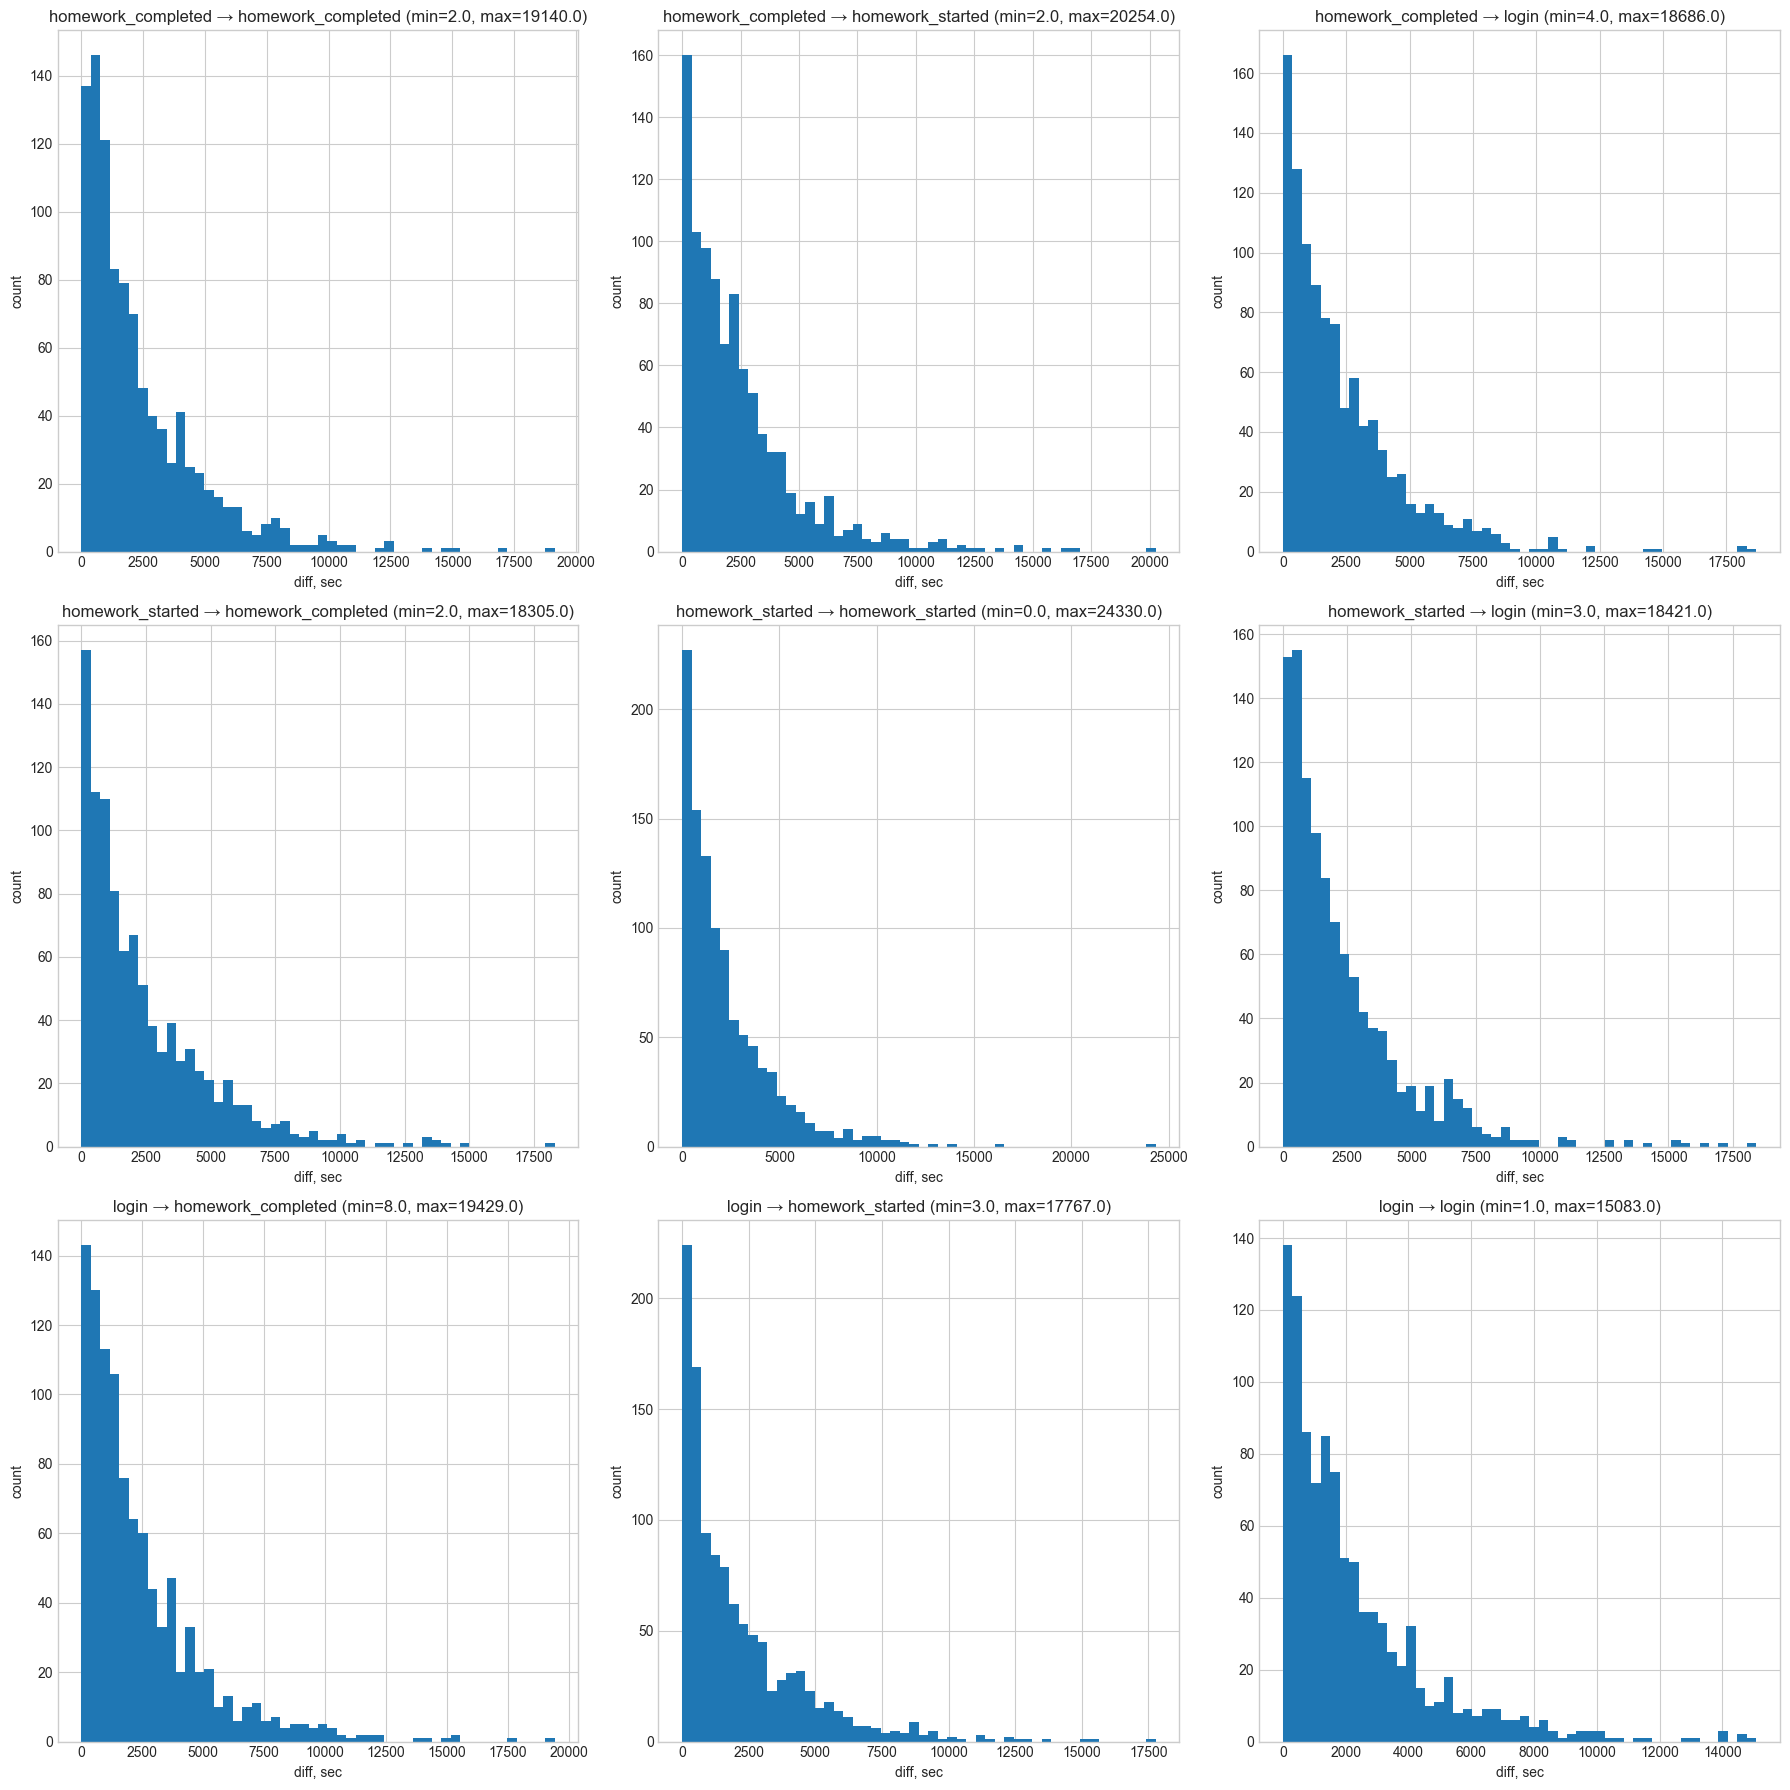

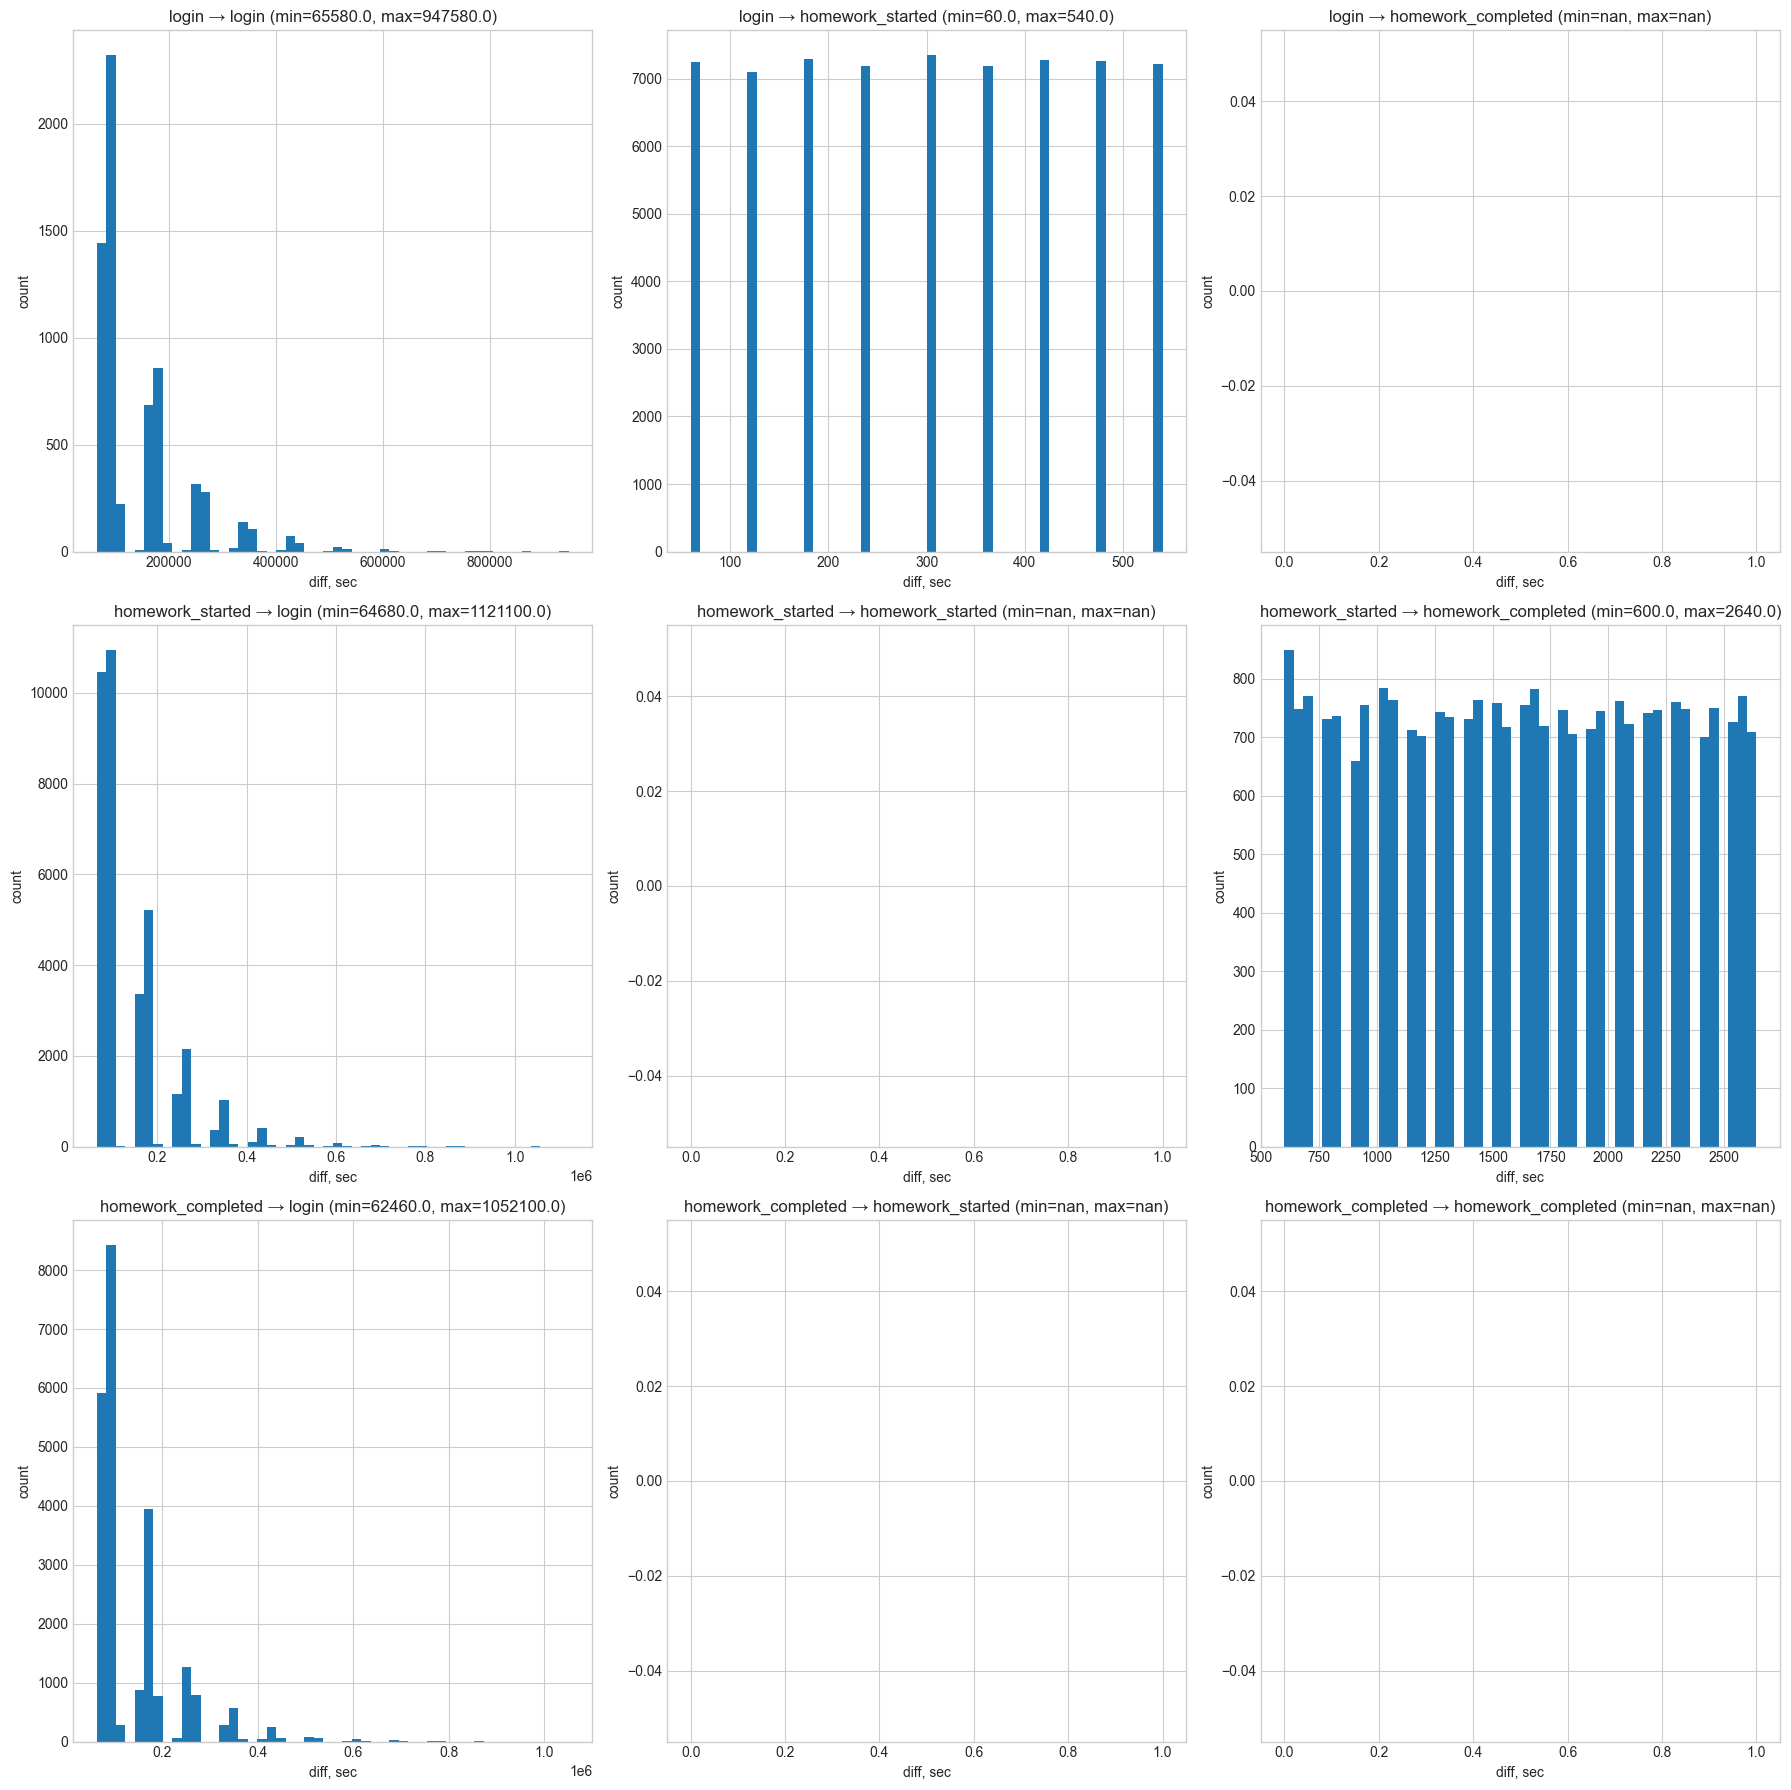

In [11]:
def plot_event_transition_matrix(df, exclude_events=None, n_bins=50, figsize=18):
    df = df.copy()

    if exclude_events:
        df = df[~df['event_type'].isin(exclude_events)]

    df = df.sort_values(['user_id', 'timestamp'])

    df['prev_event'] = df.groupby('user_id')['event_type'].shift()
    df['diff'] = df.groupby('user_id')['timestamp'].diff().dt.total_seconds()
    
    event_types = df['event_type'].unique()
    n = len(event_types)

    fig, axes = plt.subplots(n, n, figsize=(figsize, figsize))

    for i, from_event in enumerate(event_types):
        for j, to_event in enumerate(event_types):
            x = df[
                (df['prev_event'] == from_event) &
                (df['event_type'] == to_event)
            ]['diff'].dropna()
            
            axes[i, j].hist(x, bins=n_bins)
            axes[i, j].set_title(f'{from_event} → {to_event} (min={x.min()}, max={x.max()})')
            axes[i, j].set_xlabel('diff, sec')
            axes[i, j].set_ylabel('count')

    plt.tight_layout()
    plt.show()


plot_event_transition_matrix(
    df_bots,
    exclude_events=['return_visit_d7', 'return_visit_d14'],
    n_bins=50,
)

plot_event_transition_matrix(
    df_clean,
    exclude_events=['return_visit_d7', 'return_visit_d14'],
    n_bins=50,
)

In [12]:
# Видно что матрицы ботов и остальных юзеров отличаются критически. От подозрительных переходов между event, до идельно гладких распределений переходов

# df_clean данные кажутся сгенерированными, раз столь дискретны login -> homework_started
# Если датасет исходно сгенерированный - то нормально


=== diff ===
mean: 58445.3126
std:  88259.4136
skew: 2.2127
min: 0.0000
max: 1118820.0000

Quantiles:
 0.0010       60.0000
0.0100       60.0000
0.0500      120.0000
0.1000      180.0000
0.2500      360.0000
0.3500      480.0000
0.5000     1860.0000
0.6000    72900.0000
0.7000    84300.0000
0.7500    88620.0000
0.8000    94020.0000
0.9500   252240.0000
0.9900   358440.0000
0.9990   604988.8800
Name: diff, dtype: float64


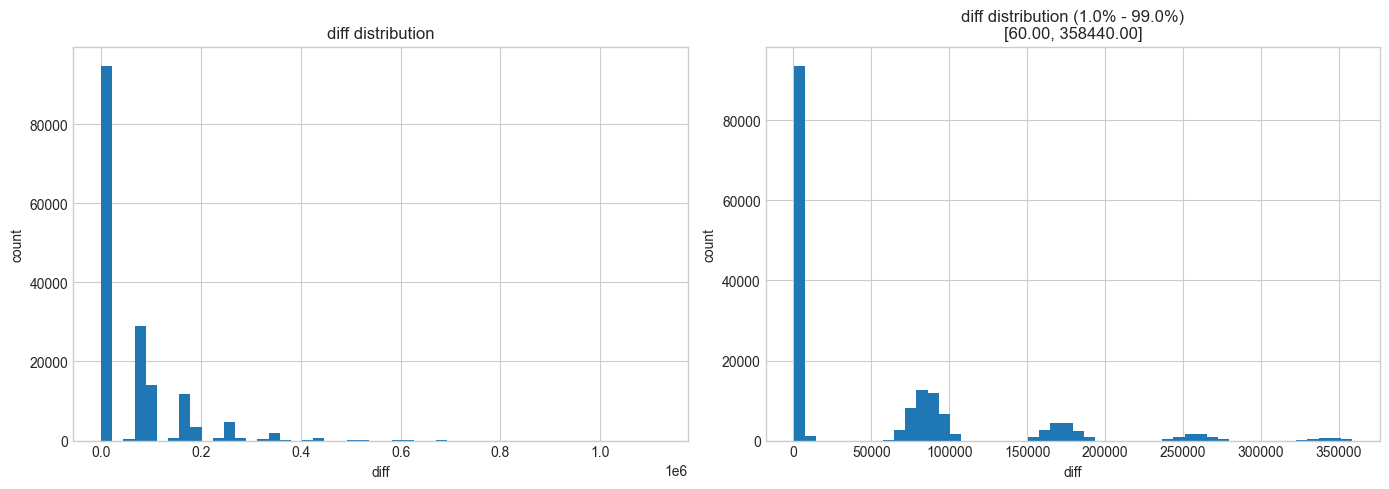

In [13]:
df_diff = df_clean.copy().sort_values(['user_id', 'timestamp'])
df_diff['diff'] = df_diff.groupby('user_id')['timestamp'].diff().dt.total_seconds()
df_diff = df_diff.dropna(subset=['diff'])
   
show_distribution(
    df_diff,
    'diff',
    quantiles = QUANTILES_LIST,
    quantile_range = (0.01, 0.99)
)

In [14]:
# 0.5 -> 0.6 по квантилю
# вероятно переход от внутрисессионными и межсессионными интервалами
# 1860 сек ~ 31 мин.
# 72780 сек ~ 20.2 часа


=== grade ===
mean: 7.8258
std:  1.9845
skew: 0.1260
min: 5.0000
max: 11.0000

Quantiles:
 Series([], Name: grade, dtype: float64)


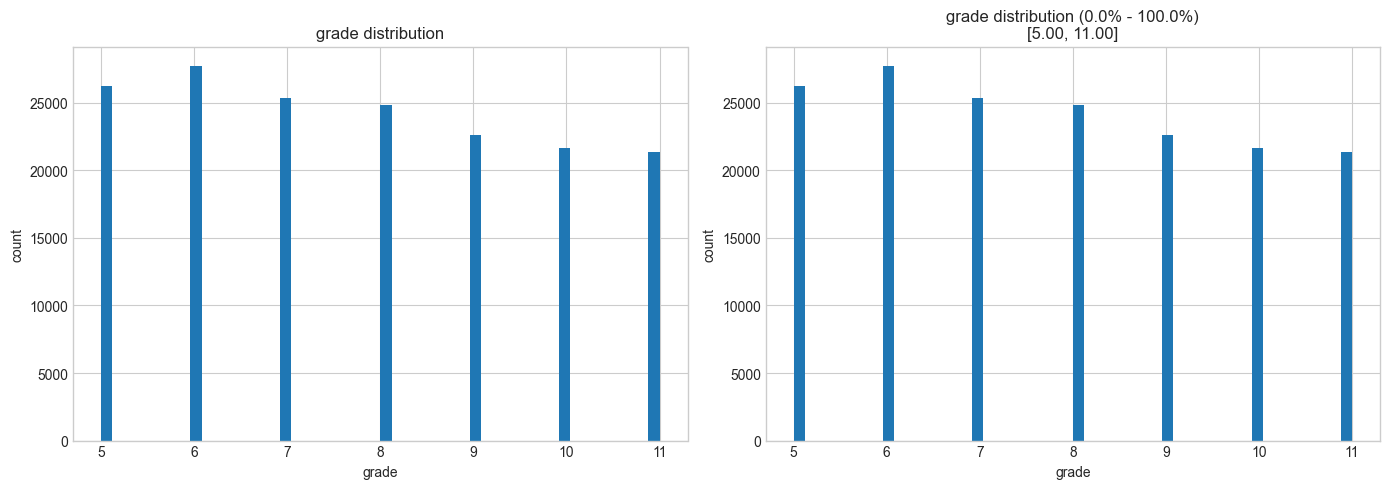

In [15]:
show_distribution(
    df_clean,
    'grade',
    quantiles=[],
    quantile_range=(0.0, 1.0)
)

### 1.3 Удаление пересечений между группами (Sample Contamination)

In [16]:
# Пользователи, попавшие в обе группы
# были удалены ещё на 1.1 как повторяющиеся в таблице df_groups пользователи
user_groups = df_clean.groupby('user_id')['group'].nunique()
overlap_users = user_groups[user_groups > 1].index

print('Пользователи в обеих группах:', overlap_users.tolist())
print('Количество:', len(overlap_users))

# Удаляем их
df_clean = df_clean[
    ~df_clean['user_id'].isin(overlap_users)
].copy()

print_ab_info(df_clean)

Пользователи в обеих группах: []
Количество: 0

Dataset Shape: (169833, 6)
Number Unique user_id: 5980
       n_rows  n_users  n_rows/n_users
group                                 
A       79190     2992         26.4672
B       90643     2988         30.3357



### 1.4 Sample Ratio Mismatch (SRM)

In [17]:
counts = (
    df_clean
    .groupby('group')['user_id']
    .nunique()
    .sort_index()
)

print('Фактическое распределение:', counts.to_dict())

expected = [counts.sum() / 2] * 2

chi2_srm, p_srm = chisquare(
    counts.values,
    expected
)

print(f'SRM χ² = {chi2_srm:.4f}, p-value = {p_srm:.4f}')

Фактическое распределение: {'A': 2992, 'B': 2988}
SRM χ² = 0.0027, p-value = 0.9587


### 1.5 SRM по grade

In [18]:
user_grade_group = (
    df_clean[['user_id', 'grade', 'group']]
    .drop_duplicates('user_id')
)

grade_counts = pd.crosstab(
    user_grade_group['grade'],
    user_grade_group['group']
)

print(grade_counts.div(grade_counts.sum(axis=1), axis=0).round(3))

chi2_grade, p_grade, _, _ = stats.chi2_contingency(grade_counts)

print(f'\nSRM χ² по классам = {chi2_grade:.3f}, p-value = {p_grade:.3f}')

if p_grade > 0.05:
    print('✓ Распределение пользователей по классам и группам не показывает статистически значимого перекоса')
else:
    print('⚠ Обнаружен перекос распределения пользователей по классам — требуется исследование')

group        A      B
grade                
5.0000  0.5170 0.4830
6.0000  0.4910 0.5090
7.0000  0.4800 0.5200
8.0000  0.5130 0.4870
9.0000  0.5320 0.4680
10.0000 0.4830 0.5170
11.0000 0.4870 0.5130

SRM χ² по классам = 8.012, p-value = 0.237
✓ Распределение пользователей по классам и группам не показывает статистически значимого перекоса


In [19]:
# Проблем с пересечением и SRM не обнаружено. Лёгкий дисбаланс внутри классов 5-11 не критичен

## 2. Анализ данных

### 2.1 Создание продуктовых метрик

In [20]:
def compute_product_metrics(df, thrs):
    user_metrics = (
        df.groupby(['user_id', 'group', 'grade'])
        .agg(
            logins=('event_type', lambda x: (x == 'login').sum()),
            homework_started=('event_type', lambda x: (x == 'homework_started').sum()),
            homework_completed=('event_type', lambda x: (x == 'homework_completed').sum()),
            active_days=('timestamp', lambda x: x.dt.date.nunique()),
            d7_return=('event_type', lambda x: (x == 'return_visit_d7').sum() > 0),
            d14_return=('event_type', lambda x: (x == 'return_visit_d14').sum() > 0),
        )
        .reset_index()
    )

    user_metrics['has_started'] = user_metrics['homework_started'] > 0
    user_metrics['has_completed'] = user_metrics['homework_completed'] > 0

    # Сколько ДЗ всего в курсе для данного класса: максимум внутри grade (обе группы вместе)
    # Предполагаем, что максимум среди количества начинаний или окончаний курса - и есть количество задач на курсе.
    user_metrics['total_hw'] = (
        user_metrics[['homework_started', 'homework_completed']].max(axis=1)
        .groupby(user_metrics['grade']).transform('max')
    )

    # Доля пройденных ДЗ от всех ДЗ курса
    user_metrics['completion_ratio'] = user_metrics['homework_completed'] / user_metrics['total_hw']
    for thr in thrs:
        user_metrics[f'completed_{int(thr*100)}pct'] = user_metrics['completion_ratio'] >= thr

    # Completion Rate из ТЗ: полное прохождение = завершил все ДЗ курса
    user_metrics['full_completion'] = user_metrics['homework_completed'] >= user_metrics['total_hw']

    first_started = (
        df[df['event_type'] == 'homework_started']
        .groupby('user_id')['timestamp']
        .min()
        .rename('first_started')
    )

    first_completed = (
        df[df['event_type'] == 'homework_completed']
        .groupby('user_id')['timestamp']
        .min()
        .rename('first_completed')
    )

    ttv = pd.concat([first_started, first_completed], axis=1).dropna()
    ttv['ttv_minutes'] = (ttv['first_completed'] - ttv['first_started']).dt.total_seconds() / 60

    user_metrics = user_metrics.merge(
        ttv[['ttv_minutes']],
        left_on='user_id',
        right_index=True,
        how='left'
    )
    return user_metrics

thrs=[0.25, 0.5, 0.75, 0.9]
user_metrics = compute_product_metrics(df_clean, thrs)
print('Пользователей в анализе:', user_metrics['user_id'].nunique())
print('Пользователей с рассчитанным TTV:', user_metrics['ttv_minutes'].notna().sum())
print("Доля юзеров которые выполнили все ДЗ:")
print(user_metrics.groupby('group')['full_completion'].mean())
print("Среднее значение доли выполненных ДЗ:")
print(user_metrics.groupby('group')['completion_ratio'].mean())
print("Доля пользователей с пройденным порогом выполненных ДЗ:")
print(user_metrics.groupby('group')[[f'completed_{int(x*100)}pct' for x in thrs]].mean())
user_metrics.head()

Пользователей в анализе: 5980
Пользователей с рассчитанным TTV: 5874
Доля юзеров которые выполнили все ДЗ:
group
A   0.0000
B   0.0000
Name: full_completion, dtype: float64
Среднее значение доли выполненных ДЗ:
group
A   0.1991
B   0.2818
Name: completion_ratio, dtype: float64
Доля пользователей с пройденным порогом выполненных ДЗ:
       completed_25pct  completed_50pct  completed_75pct  completed_90pct
group                                                                    
A               0.3118           0.0067           0.0000           0.0000
B               0.5867           0.0843           0.0007           0.0000


,user_id,group,grade,logins,homework_started,homework_completed,active_days,d7_return,d14_return,has_started,has_completed,total_hw,completion_ratio,completed_25pct,completed_50pct,completed_75pct,completed_90pct,full_completion,ttv_minutes
0,U300000,B,5.0000,14,11,6,15,True,True,True,True,19,0.3158,True,False,False,False,False,5732.0000
1,U300001,B,9.0000,14,11,3,15,True,True,True,True,18,0.1667,False,False,False,False,False,10170.0000
2,U300002,B,9.0000,12,11,4,13,True,True,True,True,18,0.2222,False,False,False,False,False,5821.0000
3,U300003,A,5.0000,10,10,3,11,True,True,True,True,19,0.1579,False,False,False,False,False,7046.0000
4,U300004,B,11.0000,13,12,3,14,True,False,True,True,16,0.1875,False,False,False,False,False,43.0000


### 2.2 Воронка конверсии

In [21]:
thr_cols = [f'completed_{round(x*100)}pct' for x in thrs]

funnel = user_metrics.groupby('group').agg(
    users=('user_id', 'count'),
    logged_in=('logins', lambda x: (x > 0).sum()),
    started=('has_started', 'sum'),
    completed_1hw=('has_completed', 'sum'),
    **{c: (c, 'sum') for c in thr_cols}
)

steps = ['users', 'logged_in', 'started', 'completed_1hw'] + thr_cols

# конверсия относительно предыдущего шага и от всех пользователей
for prev, cur in zip(steps[:-1], steps[1:]):
    funnel[f'{cur}__step'] = funnel[cur] / funnel[prev]
for s in steps[1:]:
    funnel[f'{s}__of_users'] = funnel[s] / funnel['users']

funnel.T

group,A,B
users,2992.0000,2988.0000
logged_in,2992.0000,2988.0000
started,2992.0000,2988.0000
completed_1hw,2921.0000,2953.0000
completed_25pct,933.0000,1753.0000
completed_50pct,20.0000,252.0000
completed_75pct,0.0000,2.0000
completed_90pct,0.0000,0.0000
logged_in__step,1.0000,1.0000
started__step,1.0000,1.0000


### 2.3 Ключевые метрики по группам

In [22]:
summary = user_metrics.groupby('group').agg(
    n=('user_id', 'count'),
    n_ttv=('ttv_minutes', 'count'),
    d7_retention=('d7_return', 'mean'),
    d14_retention=('d14_return', 'mean'),
    active_days=('active_days', 'mean'),
    completion_ratio=('completion_ratio', 'mean'),
    median_completion_ratio=('completion_ratio', 'median'),
    completed_25pct=('completed_25pct', 'mean'),
    completed_50pct=('completed_50pct', 'mean'),
    has_completed_1hw=('has_completed', 'mean'),
    avg_hw_completed=('homework_completed', 'mean'),
    avg_hw_started=('homework_started', 'mean'),
    median_hw_completed=('homework_completed', 'median'),
    avg_ttv_minutes=('ttv_minutes', 'mean'),
    median_ttv_minutes=('ttv_minutes', 'median'),
).T
summary

group,A,B
n,2992.0000,2988.0000
n_ttv,2921.0000,2953.0000
d7_retention,0.7269,0.7798
d14_retention,0.2881,0.3624
active_days,11.9616,13.1262
completion_ratio,0.1991,0.2818
median_completion_ratio,0.1875,0.2778
completed_25pct,0.3118,0.5867
completed_50pct,0.0067,0.0843
has_completed_1hw,0.9763,0.9883


### 2.4 Сегментация по классам

In [23]:
def pivot_metric(metric, aggfunc='mean'):
    p = user_metrics.pivot_table(index='grade', columns='group', values=metric, aggfunc=aggfunc)
    p['diff'] = p['B'] - p['A']
    p['rel_lift_%'] = (p['diff'] / p['A'].replace(0, np.nan) * 100).round(1)
    return p

print('=== D7 Retention ===')
display(pivot_metric('d7_return').round(4))

print('\n=== D14 Retention ===')
display(pivot_metric('d14_return').round(4))

print('\n=== Completion Ratio (доля пройденного курса) ===')
display(pivot_metric('completion_ratio').round(4))

print('\n=== Completed >= 25% курса ===')
display(pivot_metric('completed_25pct').round(4))

print('\n=== Completed >= 50% курса ===')
display(pivot_metric('completed_50pct').round(4))

print('\n=== Avg Homework Completed ===')
display(pivot_metric('homework_completed').round(2))

print('\n=== Median Time to Value (minutes) ===')
display(pivot_metric('ttv_minutes', aggfunc='median').round(1))

=== D7 Retention ===


group,A,B,diff,rel_lift_%
grade,,,,
5.0000,0.7287,0.8245,0.0958,13.1000
6.0000,0.7556,0.8658,0.1102,14.6000
7.0000,0.7065,0.8460,0.1395,19.7000
8.0000,0.7357,0.7749,0.0393,5.3000
9.0000,0.7163,0.7836,0.0674,9.4000
10.0000,0.7139,0.6986,-0.0153,-2.1000
11.0000,0.7284,0.6604,-0.0680,-9.3000



=== D14 Retention ===


group,A,B,diff,rel_lift_%
grade,,,,
5.0000,0.2848,0.4351,0.1503,52.8000
6.0000,0.3004,0.4589,0.1584,52.7000
7.0000,0.2612,0.4391,0.1779,68.1000
8.0000,0.2885,0.3457,0.0572,19.8000
9.0000,0.2930,0.3456,0.0526,18.0000
10.0000,0.3154,0.2603,-0.0551,-17.5000
11.0000,0.2716,0.2459,-0.0257,-9.5000



=== Completion Ratio (доля пройденного курса) ===


...

group,A,B,diff,rel_lift_%
grade,,,,
5.0000,0.0022,0.1202,0.1180,5260.6000
6.0000,0.0022,0.2229,0.2207,9843.3000
7.0000,0.0050,0.1632,0.1582,3180.7000
8.0000,0.0022,0.0139,0.0117,532.0000
9.0000,0.0093,0.0422,0.0329,353.8000
10.0000,0.0098,0.0023,-0.0075,-76.7000
11.0000,0.0173,0.0117,-0.0056,-32.3000



=== Avg Homework Completed ===


group,A,B,diff,rel_lift_%
grade,,,,
5.0000,3.6300,6.8800,3.2500,89.4000
6.0000,3.4900,6.7400,3.2500,93.3000
7.0000,3.6700,6.3600,2.6900,73.4000
8.0000,3.5300,4.8500,1.3200,37.4000
9.0000,3.5200,4.9100,1.4000,39.7000
10.0000,3.6500,2.9900,-0.6600,-18.0000
11.0000,3.5900,2.9300,-0.6600,-18.3000



=== Median Time to Value (minutes) ===


group,A,B,diff,rel_lift_%
grade,,,,
5.0000,2858.0000,41.0000,-2817.0000,-98.6000
6.0000,2802.5000,40.0000,-2762.5000,-98.6000
7.0000,2929.0000,43.0000,-2886.0000,-98.5000
8.0000,1703.0000,1463.0000,-240.0000,-14.1000
9.0000,4108.0000,1412.0000,-2696.0000,-65.6000
10.0000,2756.0000,4038.0000,1282.0000,46.5000
11.0000,3006.5000,4029.0000,1022.5000,34.0000


### 2.5 Графики распределений метрик

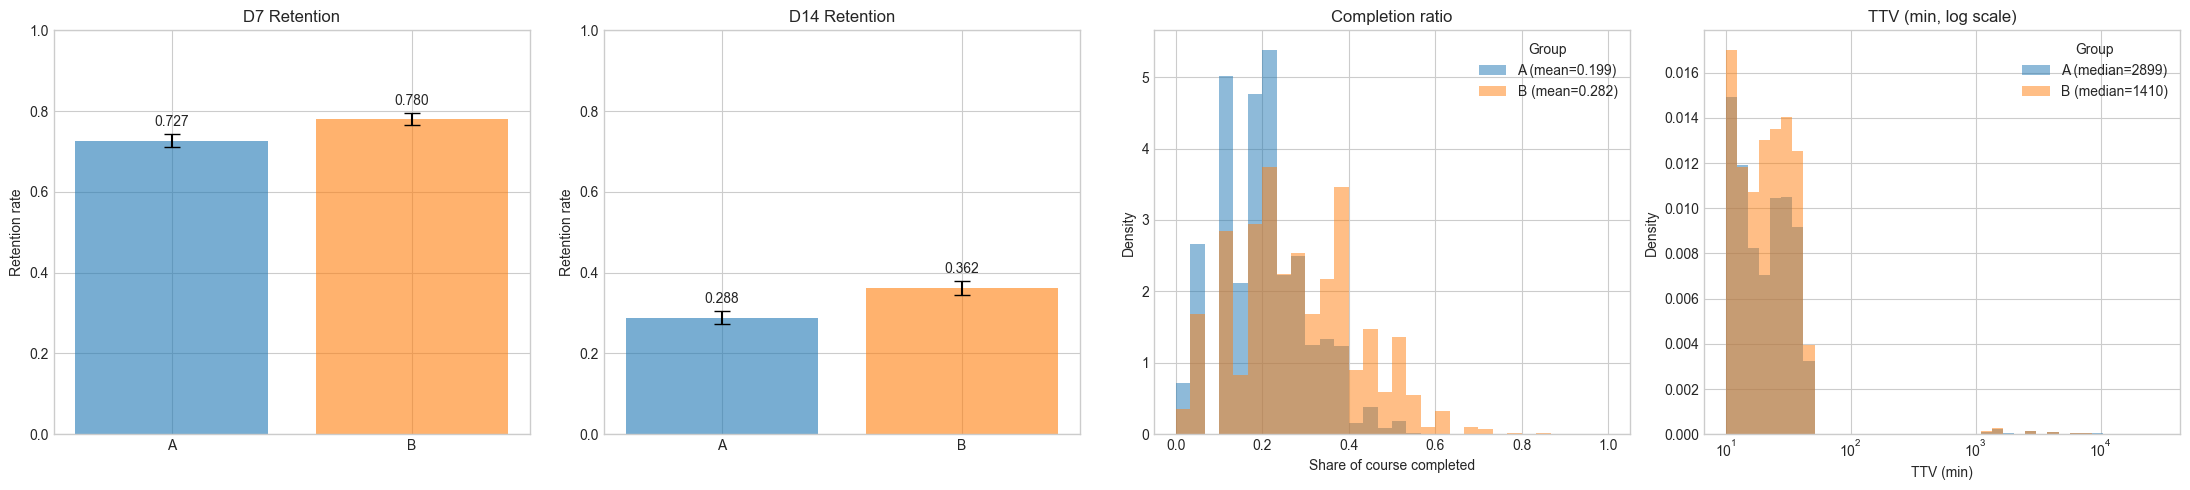

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
colors = {'A': 'tab:blue', 'B': 'tab:orange'}

# -------------------------
# D7 / D14 Retention с 95% CI (Wilson)
# -------------------------
for ax, col, title in [(axes[0], 'd7_return', 'D7 Retention'),
                       (axes[1], 'd14_return', 'D14 Retention')]:
    for group in ['A', 'B']:
        values = user_metrics.loc[user_metrics['group'] == group, col].dropna()
        k, n = values.sum(), len(values)
        lo, hi = proportion_confint(k, n, method='wilson')
        ax.bar([group], [values.mean()], alpha=0.6, color=colors[group],
               yerr=[[values.mean() - lo], [hi - values.mean()]], capsize=6)
        ax.text(group, hi + 0.02, f'{values.mean():.3f}', ha='center')
    ax.set_title(title)
    ax.set_ylabel('Retention rate')
    ax.set_ylim(0, 1)

# -------------------------
# Completion ratio (доля пройденного курса)
# -------------------------
bins = np.linspace(0, 1, 31)
for group in ['A', 'B']:
    values = user_metrics.loc[user_metrics['group'] == group, 'completion_ratio'].dropna()
    axes[2].hist(values, bins=bins, alpha=0.5, density=True,
                 color=colors[group], label=f'{group} (mean={values.mean():.3f})')

axes[2].set_title('Completion ratio')
axes[2].set_xlabel('Share of course completed')
axes[2].set_ylabel('Density')
axes[2].legend(title='Group')

# -------------------------
# TTV (лог-шкала: распределение сильно скошено)
# -------------------------
ttv_pos = user_metrics['ttv_minutes'].dropna()
ttv_pos = ttv_pos[ttv_pos > 0]
bins_ttv = np.logspace(np.log10(ttv_pos.min()), np.log10(ttv_pos.max()), 40)
for group in ['A', 'B']:
    values = user_metrics.loc[user_metrics['group'] == group, 'ttv_minutes'].dropna()
    values = values[values > 0]
    axes[3].hist(values, bins=bins_ttv, alpha=0.5, density=True,
                 color=colors[group], label=f'{group} (median={values.median():.0f})')

axes[3].set_xscale('log')
axes[3].set_title('TTV (min, log scale)')
axes[3].set_xlabel('TTV (min)')
axes[3].set_ylabel('Density')
axes[3].legend(title='Group')

plt.tight_layout()
plt.show()

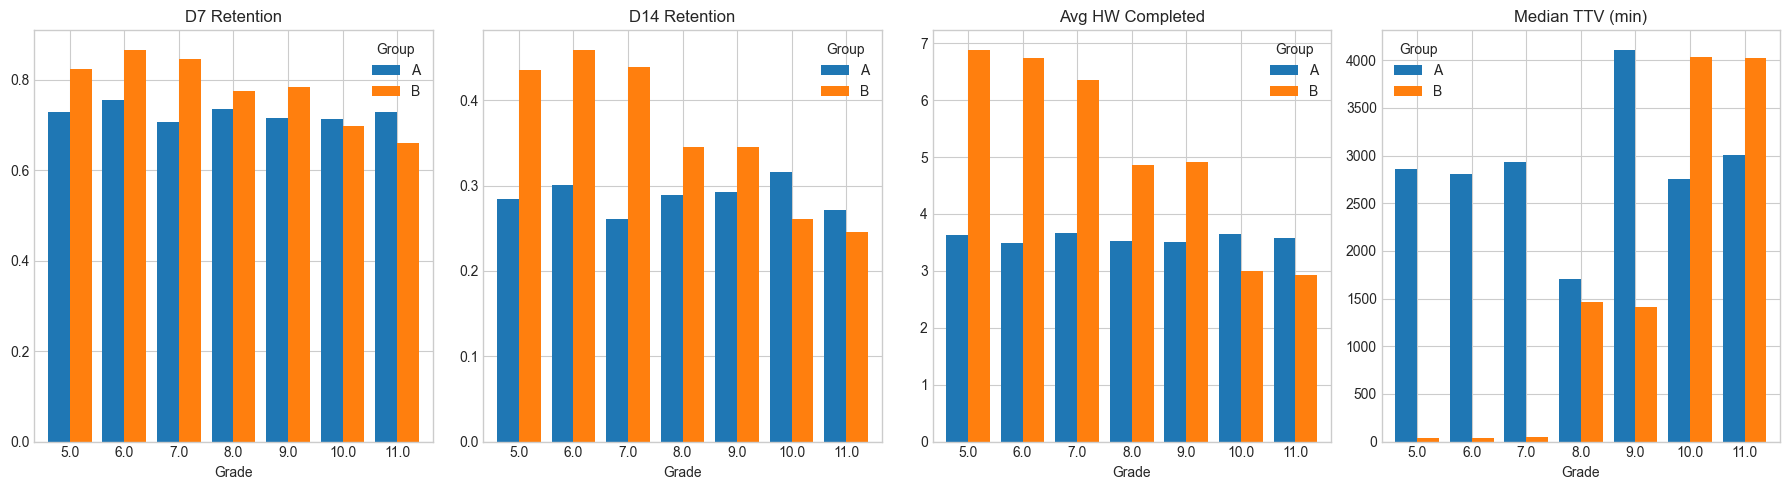

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric, title, agg in zip(
    axes,
    ['d7_return', 'd14_return', 'homework_completed', 'ttv_minutes'],
    ['D7 Retention', 'D14 Retention', 'Avg HW Completed', 'Median TTV (min)'],
    ['mean', 'mean', 'mean', 'median']
):
    p = pivot_metric(metric, aggfunc=agg)
    p[['A', 'B']].plot(kind='bar', ax=ax, width=0.8)
    ax.set_title(title)
    ax.set_xlabel('Grade')
    ax.legend(title='Group')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'metrics_by_grade.png'), dpi=150, bbox_inches='tight')
plt.show()

**Наблюдение:** эффект геймификации сильно зависит от возраста:
- **5–7 классы** — выраженный положительный эффект
- **8-9 классы** - положительный эффект
- **10–11 классы** — нейтральный / отрицательный эффект

## 3. Статистика

### 3.1 Тесты бинарных метрик

In [26]:
def proportion_test(df, metric, group_col='group'):
    """Z-тест (Фишер при малых счётчиках) + 95% CI разницы (Newcombe)"""
    a = df[df[group_col] == 'A'][metric].astype(float)
    b = df[df[group_col] == 'B'][metric].astype(float)
    xa, xb, na, nb = int(a.sum()), int(b.sum()), len(a), len(b)

    _, p_z = proportions_ztest([xb, xa], [nb, na])
    _, p_f = fisher_exact([[xb, nb - xb], [xa, na - xa]])
    small = min(xa, xb, na - xa, nb - xb) < 10          # мало событий -> доверяем Фишеру
    p_value = p_f if small else p_z

    lo, hi = confint_proportions_2indep(xb, nb, xa, na, method='newcomb')
    pa, pb = xa / na, xb / nb

    return {
        'metric': metric, 'A_value': pa, 'B_value': pb, 'diff': pb - pa,
        'rel_lift_%': (pb - pa) / pa * 100 if pa > 0 else np.nan,
        'p_value': p_value, 'test': 'fisher' if small else 'z',
        'ci_low': lo, 'ci_high': hi, 'n_A': na, 'n_B': nb,
    }

metrics = ['d7_return', 'd14_return', 'completed_25pct', 'completed_50pct']
descrete_results_df = pd.DataFrame([proportion_test(user_metrics, m) for m in metrics])
display(descrete_results_df)

,metric,A_value,B_value,diff,rel_lift_%,p_value,test,ci_low,ci_high,n_A,n_B
0,d7_return,0.7269,0.7798,0.0528,7.2698,0.0000,z,0.0310,0.0746,2992,2988
1,d14_return,0.2881,0.3624,0.0743,25.8062,0.0000,z,0.0506,0.0980,2992,2988
2,completed_25pct,0.3118,0.5867,0.2748,88.1401,0.0000,z,0.2504,0.2988,2992,2988
3,completed_50pct,0.0067,0.0843,0.0777,1161.6867,0.0000,z,0.0675,0.0884,2992,2988


### 3.2 Тесты непрерывных метрик

In [27]:
def bootstrap_ci(b_values, a_values, stat=np.mean, ci_percentile=[2.5, 97.5], n_boot=10000, seed=42):
    rng = np.random.default_rng(seed)
    b_idx = rng.integers(0, len(b_values), size=(n_boot, len(b_values)))
    a_idx = rng.integers(0, len(a_values), size=(n_boot, len(a_values)))
    diffs = stat(b_values[b_idx], axis=1) - stat(a_values[a_idx], axis=1)
    return np.percentile(diffs, ci_percentile)

# метрика -> статистика, по которой строим разницу и CI
cont_metrics = {
    'completion_ratio': np.mean,
    'homework_completed': np.mean,
    'ttv_minutes': np.median,   # скошенное распределение, только среди завершивших ДЗ
}

cont_results = []

for metric, stat in cont_metrics.items():
    a = user_metrics.loc[
        user_metrics['group'] == 'A', metric
    ].dropna().values

    b = user_metrics.loc[
        user_metrics['group'] == 'B', metric
    ].dropna().values

    ci_low, ci_high = bootstrap_ci(b, a, stat=stat)

    u_stat, p_mwu = stats.mannwhitneyu(
        b, a,
        alternative='two-sided'
    )

    value_a = stat(a)
    value_b = stat(b)

    cont_results.append({
        'metric': metric,
        'A_value': value_a,
        'B_value': value_b,
        'diff': value_b - value_a,
        'rel_lift_%': (
            (value_b - value_a) / value_a * 100
            if value_a != 0 else np.nan
        ),
        'p_value': p_mwu,
        'test': 'mann-whitney',
        'ci_low': ci_low,
        'ci_high': ci_high,
        'n_A': len(a),
        'n_B': len(b),
    })

cont_results_df = pd.DataFrame(cont_results)
display(cont_results_df)

,metric,A_value,B_value,diff,rel_lift_%,p_value,test,ci_low,ci_high,n_A,n_B
0,completion_ratio,0.1991,0.2818,0.0826,41.5058,0.0000,mann-whitney,0.0765,0.0886,2992,2988
1,homework_completed,3.5802,5.1068,1.5265,42.6384,0.0000,mann-whitney,1.4138,1.6359,2992,2988
2,ttv_minutes,2899.0000,1410.0000,-1489.0000,-51.3625,0.0000,mann-whitney,-1600.0000,-1370.0000,2921,2953


In [28]:
# Holm коррекция для множественного A/B
results_df = pd.concat(
    [descrete_results_df, cont_results_df],
    ignore_index=True
)
results_df['p_holm'] = multipletests(results_df['p_value'], method='holm')[1]

display(results_df)

,metric,A_value,B_value,diff,rel_lift_%,p_value,test,ci_low,ci_high,n_A,n_B,p_holm
0,d7_return,0.7269,0.7798,0.0528,7.2698,0.0000,z,0.0310,0.0746,2992,2988,0.0000
1,d14_return,0.2881,0.3624,0.0743,25.8062,0.0000,z,0.0506,0.0980,2992,2988,0.0000
2,completed_25pct,0.3118,0.5867,0.2748,88.1401,0.0000,z,0.2504,0.2988,2992,2988,0.0000
3,completed_50pct,0.0067,0.0843,0.0777,1161.6867,0.0000,z,0.0675,0.0884,2992,2988,0.0000
4,completion_ratio,0.1991,0.2818,0.0826,41.5058,0.0000,mann-whitney,0.0765,0.0886,2992,2988,0.0000
5,homework_completed,3.5802,5.1068,1.5265,42.6384,0.0000,mann-whitney,1.4138,1.6359,2992,2988,0.0000
6,ttv_minutes,2899.0000,1410.0000,-1489.0000,-51.3625,0.0000,mann-whitney,-1600.0000,-1370.0000,2921,2953,0.0000


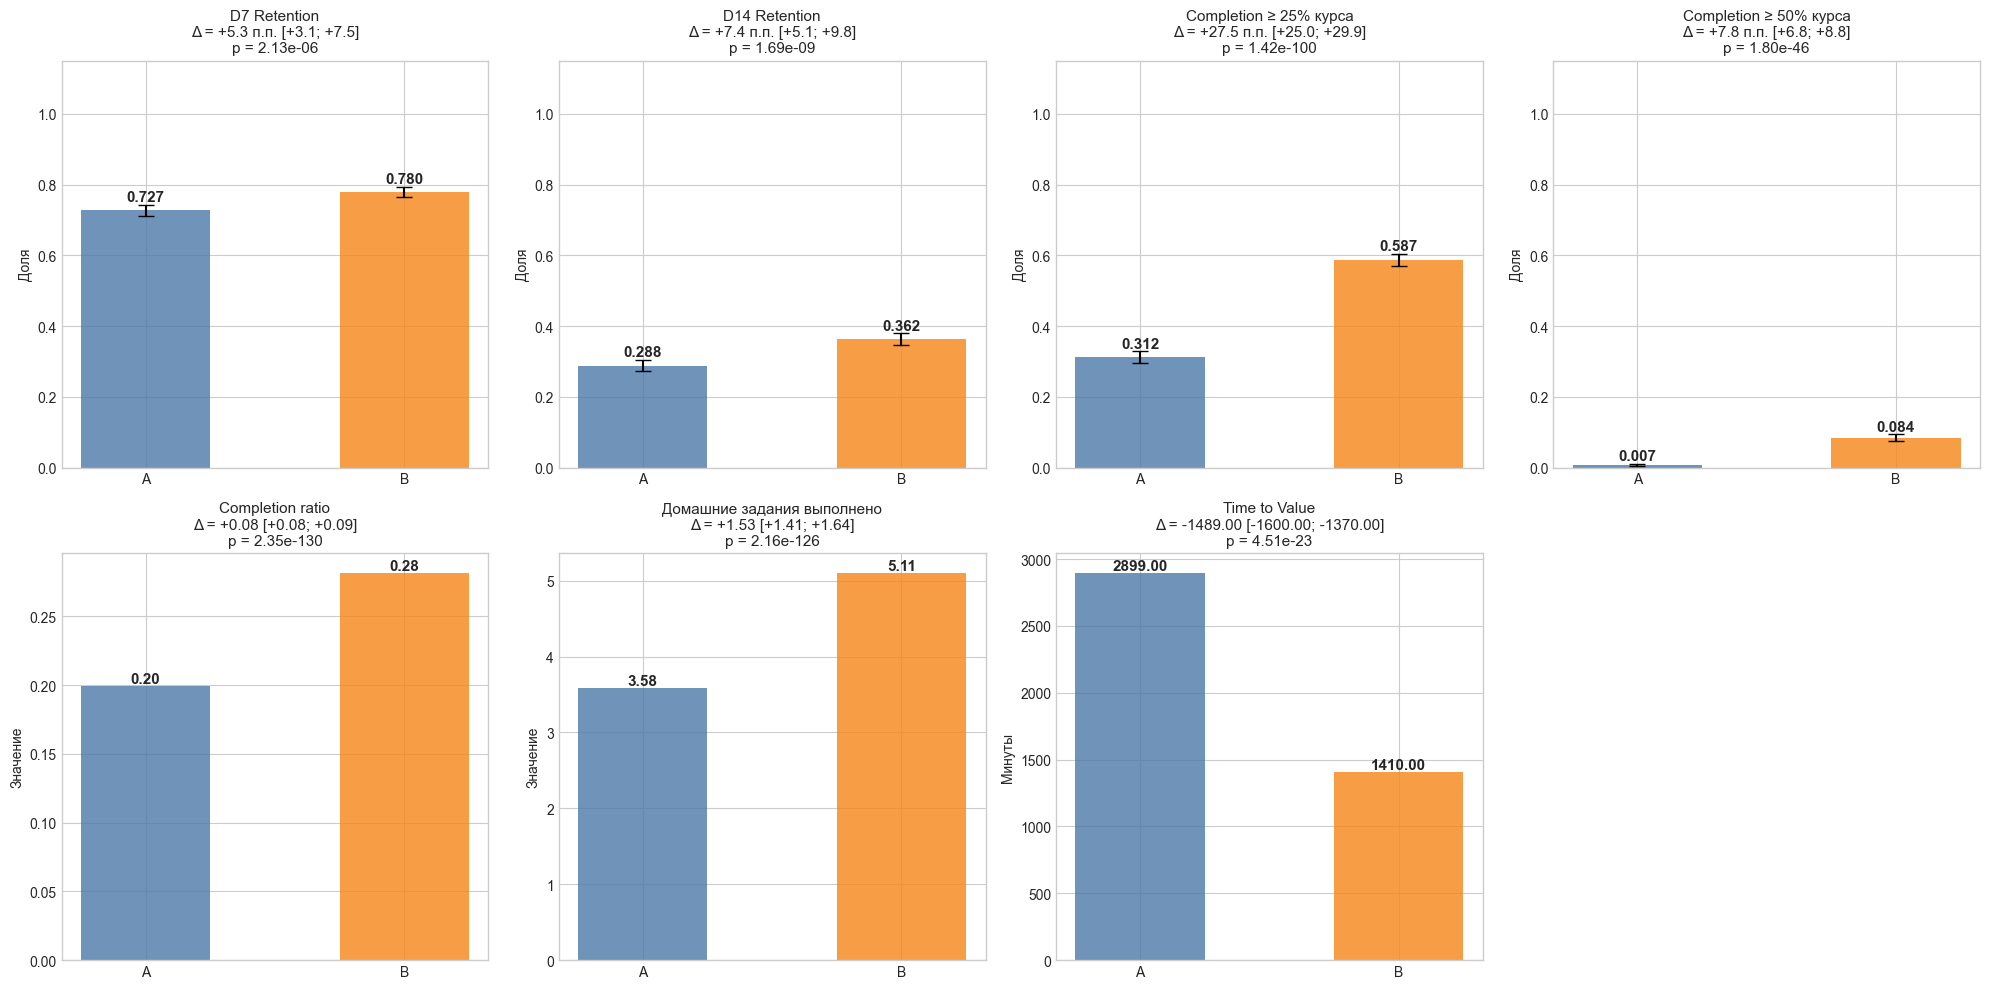

In [29]:
binary_metrics = [
    'd7_return',
    'd14_return',
    'completed_25pct',
    'completed_50pct'
]

binary_titles = [
    'D7 Retention',
    'D14 Retention',
    'Completion ≥ 25% курса',
    'Completion ≥ 50% курса'
]

continuous_metrics = [
    'completion_ratio',
    'homework_completed',
    'ttv_minutes'
]

continuous_titles = [
    'Completion ratio',
    'Домашние задания выполнено',
    'Time to Value'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# ============================================================
# БИНАРНЫЕ МЕТРИКИ
# ============================================================

for ax, metric, title in zip(
    axes[0], binary_metrics, binary_titles
):
    for group, color in zip(['A', 'B'], ['#4C78A8', '#F58518']):
        x = user_metrics.loc[
            user_metrics['group'] == group, metric
        ].astype(int)

        k, n = x.sum(), len(x)
        p = k / n

        lo, hi = proportion_confint(
            k, n,
            method='wilson'
        )

        ax.bar(
            group,
            p,
            color=color,
            alpha=0.8,
            width=0.5,
            yerr=[[p - lo], [hi - p]],
            capsize=6,
            error_kw=dict(
                lw=1.5,
                ecolor='black'
            )
        )

        ax.text(
            group,
            hi + 0.01,
            f'{p:.3f}',
            ha='center',
            fontsize=11,
            fontweight='bold'
        )

    r = results_df[
        results_df['metric'] == metric
    ].iloc[0]

    ax.set_title(
        f'{title}\n'
        f'Δ = {r["diff"] * 100:+.1f} п.п. '
        f'[{r["ci_low"] * 100:+.1f}; '
        f'{r["ci_high"] * 100:+.1f}]\n'
        f'p = {r["p_holm"]:.2e}',
        fontsize=11
    )

    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Доля')


# ============================================================
# НЕПРЕРЫВНЫЕ МЕТРИКИ
# ============================================================

for ax, metric, title in zip(
    axes[1, :3],
    continuous_metrics,
    continuous_titles
):
    r = results_df[
        results_df['metric'] == metric
    ].iloc[0]

    values = {
        'A': r['A_value'],
        'B': r['B_value']
    }

    ax.bar(
        ['A', 'B'],
        [values['A'], values['B']],
        color=['#4C78A8', '#F58518'],
        alpha=0.8,
        width=0.5
    )

    # Подписи значений
    for group in ['A', 'B']:
        ax.text(
            group,
            values[group],
            f'{values[group]:.2f}',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

    # CI для разницы B - A
    diff = r['diff']
    ci_low = r['ci_low']
    ci_high = r['ci_high']

    ax.set_title(
        f'{title}\n'
        f'Δ = {diff:+.2f} '
        f'[{ci_low:+.2f}; {ci_high:+.2f}]\n'
        f'p = {r["p_holm"]:.2e}',
        fontsize=11
    )

    ax.set_ylabel('Значение')


# Для TTV минуты
axes[1, 2].set_ylabel('Минуты')


# ============================================================
# ПУСТОЙ 8-Й ГРАФИК
# ============================================================

axes[1, 3].axis('off')


plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURES_PATH,
        'metrics_with_ci.png'
    ),
    dpi=150,
    bbox_inches='tight'
)

plt.show()

### 3.3 Тесты по сегментам

In [30]:
segments = {
    'grades 5-7':   user_metrics['grade'].between(5, 7),
    'grades 8-9':   user_metrics['grade'].between(8, 9),
    'grades 10-11': user_metrics['grade'].between(10, 11),
}

binary_metrics = [
    'd7_return',
    'd14_return',
    'completed_25pct',
    'completed_50pct',
]

continuous_metrics = {
    'completion_ratio': np.mean,
    'homework_completed': np.mean,
    'ttv_minutes': np.median,
}

rows = []

for segment_name, mask in segments.items():
    seg = user_metrics[mask]

    # --- Бинарные ---
    for metric in binary_metrics:
        r = proportion_test(seg, metric)
        r['segment'] = segment_name
        rows.append(r)

    # --- Непрерывные ---
    for metric, stat in continuous_metrics.items():
        a = seg.loc[
            seg['group'] == 'A', metric
        ].dropna().values

        b = seg.loc[
            seg['group'] == 'B', metric
        ].dropna().values

        ci_low, ci_high = bootstrap_ci(
            b, a,
            stat=stat,
            n_boot=10000,
            seed=42
        )

        _, p_mwu = stats.mannwhitneyu(
            b, a,
            alternative='two-sided'
        )

        value_a = stat(a)
        value_b = stat(b)

        rows.append({
            'metric': metric,
            'A_value': value_a,
            'B_value': value_b,
            'diff': value_b - value_a,
            'rel_lift_%': (
                (value_b - value_a) / value_a * 100
                if value_a != 0 else np.nan
            ),
            'p_value': p_mwu,
            'test': 'mann-whitney',
            'ci_low': ci_low,
            'ci_high': ci_high,
            'n_A': len(a),
            'n_B': len(b),
            'segment': segment_name,
        })

seg_df = pd.DataFrame(rows)

# Всего 3 сегмента × 7 метрик = 21 тест.
# Одна общая Holm-коррекция для этой семьи тестов.
seg_df['p_holm'] = multipletests(
    seg_df['p_value'],
    method='holm'
)[1]

display(
    seg_df[
        [
            'segment', 'metric',
            'A_value', 'B_value',
            'diff', 'rel_lift_%',
            'ci_low', 'ci_high',
            'p_value', 'p_holm',
            'test', 'n_A', 'n_B'
        ]
    ]
)

,segment,metric,A_value,B_value,diff,rel_lift_%,ci_low,ci_high,p_value,p_holm,test,n_A,n_B
0,grades 5-7,d7_return,0.7311,0.8462,0.1151,15.7424,0.0839,0.1460,0.0000,0.0000,z,1294,1313
1,grades 5-7,d14_return,0.2828,0.4448,0.1619,57.2539,0.1253,0.1980,0.0000,0.0000,z,1294,1313
2,grades 5-7,completed_25pct,0.2821,0.8302,0.5481,194.3088,0.5152,0.5788,0.0000,0.0000,z,1294,1313
3,grades 5-7,completed_50pct,0.0031,0.1706,0.1675,5418.9642,0.1475,0.1889,0.0000,0.0000,fisher,1294,1313
4,grades 5-7,completion_ratio,0.1961,0.3636,0.1676,85.4726,0.1590,0.1760,0.0000,0.0000,mann-whitney,1294,1313
5,grades 5-7,homework_completed,3.5951,6.6603,3.0653,85.2634,2.9092,3.2201,0.0000,0.0000,mann-whitney,1294,1313
6,grades 5-7,ttv_minutes,2843.0000,41.0000,-2802.0000,-98.5579,-2956.0000,-2642.9750,0.0000,0.0000,mann-whitney,1262,1313
7,grades 8-9,d7_return,0.7262,0.7790,0.0528,7.2659,0.0116,0.0935,0.0121,0.0724,z,884,810
8,grades 8-9,d14_return,0.2907,0.3457,0.0550,18.9028,0.0106,0.0992,0.0152,0.0759,z,884,810
9,grades 8-9,completed_25pct,0.2636,0.5481,0.2846,107.9669,0.2389,0.3286,0.0000,0.0000,z,884,810


In [31]:
# отличаются ли статистически эффекты между сегментами

um = user_metrics.assign(
    is_B=(user_metrics['group'] == 'B').astype(int),

    grade_segment=pd.cut(
        user_metrics['grade'],
        bins=[4, 7, 9, 11],
        labels=[
            'grades 5-7',
            'grades 8-9',
            'grades 10-11'
        ]
    ),

    d7=user_metrics['d7_return'].astype(int),
    d14=user_metrics['d14_return'].astype(int),
    completed_25pct=user_metrics['completed_25pct'].astype(int),
    completed_50pct=user_metrics['completed_50pct'].astype(int),
)

interaction_results = []

# ============================================================
# Бинарные метрики — Logistic Regression + LR test
# ============================================================

for metric in [
    'd7',
    'd14',
    'completed_25pct',
    'completed_50pct',
]:

    full = smf.logit(
        f'{metric} ~ is_B * C(grade_segment)',
        um
    ).fit(disp=0)

    reduced = smf.logit(
        f'{metric} ~ is_B + C(grade_segment)',
        um
    ).fit(disp=0)

    lr = 2 * (full.llf - reduced.llf)
    df_diff = full.df_model - reduced.df_model

    p_interaction = chi2.sf(lr, df_diff)

    interaction_results.append({
        'metric': metric,
        'test': 'Logistic LR',
        'statistic': lr,
        'df': df_diff,
        'p_interaction': p_interaction,
    })


# ============================================================
# Непрерывные метрики — OLS + ANOVA
# ============================================================

for metric in continuous_metrics:

    full = smf.ols(
        f'{metric} ~ is_B * C(grade_segment)',
        um
    ).fit()

    reduced = smf.ols(
        f'{metric} ~ is_B + C(grade_segment)',
        um
    ).fit()

    anova = sm.stats.anova_lm(
        reduced,
        full
    )

    p_interaction = anova.iloc[1]['Pr(>F)']

    interaction_results.append({
        'metric': metric,
        'test': 'OLS ANOVA',
        'statistic': anova.iloc[1]['F'],
        'df': anova.iloc[1]['df_diff'],
        'p_interaction': p_interaction,
    })


# ============================================================
# Holm correction
# ============================================================

interaction_df = pd.DataFrame(interaction_results)

interaction_df['p_holm'] = multipletests(
    interaction_df['p_interaction'],
    method='holm'
)[1]

display(interaction_df)

,metric,test,statistic,df,p_interaction,p_holm
0,d7,Logistic LR,38.8353,2.0000,0.0000,0.0000
1,d14,Logistic LR,45.1865,2.0000,0.0000,0.0000
2,completed_25pct,Logistic LR,550.9556,2.0000,0.0000,0.0000
3,completed_50pct,Logistic LR,59.1630,2.0000,0.0000,0.0000
4,completion_ratio,OLS ANOVA,493.1393,2.0000,0.0000,0.0000
5,homework_completed,OLS ANOVA,495.2296,2.0000,0.0000,0.0000
6,ttv_minutes,OLS ANOVA,61.9036,2.0000,0.0000,0.0000


### 3.4 Minimum Detectable Effect (MDE)

In [32]:
ALPHA = 0.05
POWER = 0.9

# Для бинарных метрик
def calculate_mde(baseline, n1, n2, alpha=0.05, power_target=0.9):
    z_alpha = norm.ppf(1 - alpha / 2)
    def power_for_delta(delta):
        p2 = baseline + delta
        se_alt = np.sqrt(baseline*(1-baseline)/n1 + p2*(1-p2)/n2)
        effect = delta / se_alt
        power = norm.cdf(-z_alpha - effect) + (1 - norm.cdf(z_alpha - effect))
        return power
    return brentq(lambda d: power_for_delta(d) - power_target, 1e-10, 1 - baseline - 1e-10)

MDE_METRICS = {
    'D7 Retention':    'd7_return',
    'D14 Retention':   'd14_return',
    'Completion ≥25%': 'completed_25pct',
    'Completion ≥50%': 'completed_50pct',
}

all_segments = {'All users': pd.Series(True, index=user_metrics.index), **segments}

rows = []
for seg_name, mask in all_segments.items():
    seg = user_metrics[mask]
    a = seg[seg['group'] == 'A']
    b = seg[seg['group'] == 'B']
    n_a_s, n_b_s = len(a), len(b)

    for label, col in MDE_METRICS.items():
        base = a[col].mean()
        mde = calculate_mde(base, n_a_s, n_b_s, ALPHA, POWER)
        rows.append({
            'segment': seg_name,
            'metric': label,
            'n_A': n_a_s,
            'n_B': n_b_s,
            'baseline': base,
            'MDE_pp': mde * 100,
        })

mde_df = pd.DataFrame(rows)
display(mde_df)

,segment,metric,n_A,n_B,baseline,MDE_pp
0,All users,D7 Retention,2992,2988,0.7269,3.6499
1,All users,D14 Retention,2992,2988,0.2881,3.8651
2,All users,Completion ≥25%,2992,2988,0.3118,3.9433
3,All users,Completion ≥50%,2992,2988,0.0067,0.8764
4,grades 5-7,D7 Retention,1294,1313,0.7311,5.4273
5,grades 5-7,D14 Retention,1294,1313,0.2828,5.8710
6,grades 5-7,Completion ≥25%,1294,1313,0.2821,5.8669
7,grades 5-7,Completion ≥50%,1294,1313,0.0031,1.1998
8,grades 8-9,D7 Retention,884,810,0.7262,6.7012
9,grades 8-9,D14 Retention,884,810,0.2907,7.3866


In [33]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm


# ============================================================
# MDE для разницы средних
# ============================================================

def calculate_mean_mde(
    a_values,
    b_values,
    alpha=0.05,
    power_target=0.9,
):
    a_values = np.asarray(a_values, dtype=float)
    b_values = np.asarray(b_values, dtype=float)

    n_a = len(a_values)
    n_b = len(b_values)

    if n_a < 2 or n_b < 2:
        return np.nan

    std_a = np.std(a_values, ddof=1)
    std_b = np.std(b_values, ddof=1)

    z_alpha = norm.ppf(1 - alpha / 2)
    z_power = norm.ppf(power_target)

    # SE разницы средних
    se = np.sqrt(
        std_a**2 / n_a +
        std_b**2 / n_b
    )

    return (z_alpha + z_power) * se


# ============================================================
# MDE для медианы через simulation + Mann-Whitney
# ============================================================

def calculate_median_mde(
    a_values,
    b_values,
    alpha=0.05,
    power_target=0.9,
    n_sim=3000,
    n_grid=100,
    seed=42,
):
    rng = np.random.default_rng(seed)

    a_values = np.asarray(a_values, dtype=float)
    b_values = np.asarray(b_values, dtype=float)

    n_a = len(a_values)
    n_b = len(b_values)

    if n_a == 0 or n_b == 0:
        return np.nan

    # Масштаб эффекта.
    # Используем IQR, чтобы выбросы TTV не раздували диапазон.
    q1, q3 = np.percentile(
        np.concatenate([a_values, b_values]),
        [25, 75]
    )

    scale = q3 - q1

    if scale == 0:
        scale = np.std(
            np.concatenate([a_values, b_values]),
            ddof=1
        )

    if scale == 0:
        return 0.0

    # Не начинаем с 0:
    # ищем минимальный положительный эффект.
    deltas = np.linspace(
        scale / 1000,
        scale,
        n_grid
    )

    for delta in deltas:

        significant = 0

        for _ in range(n_sim):

            a_sim = rng.choice(
                a_values,
                size=n_a,
                replace=True
            )

            b_sim = (
                rng.choice(
                    b_values,
                    size=n_b,
                    replace=True
                )
                + delta
            )

            _, p_value = stats.mannwhitneyu(
                b_sim,
                a_sim,
                alternative='two-sided'
            )

            significant += p_value < alpha

        power = significant / n_sim

        if power >= power_target:
            return delta

    return np.nan


# ============================================================
# Continuous MDE
# ============================================================

continuous_mde_metrics = {
    'completion_ratio': 'mean',
    'homework_completed': 'mean',
    'ttv_minutes': 'median',
}


mde_cont_rows = []

all_segments = {
    'All users': pd.Series(
        True,
        index=user_metrics.index
    ),
    **segments
}


for seg_name, mask in all_segments.items():

    seg = user_metrics[mask]

    a = seg.loc[
        seg['group'] == 'A'
    ]

    b = seg.loc[
        seg['group'] == 'B'
    ]

    for metric, stat_type in continuous_mde_metrics.items():

        a_values = (
            a[metric]
            .dropna()
            .astype(float)
            .values
        )

        b_values = (
            b[metric]
            .dropna()
            .astype(float)
            .values
        )

        # ----------------------------
        # baseline
        # ----------------------------

        if stat_type == 'mean':
            baseline = np.mean(a_values)

            mde = calculate_mean_mde(
                a_values,
                b_values,
                alpha=ALPHA,
                power_target=POWER,
            )

        # ----------------------------
        # median
        # ----------------------------

        elif stat_type == 'median':
            baseline = np.median(a_values)

            mde = calculate_median_mde(
                a_values,
                b_values,
                alpha=ALPHA,
                power_target=POWER,
                n_sim=3000,
                n_grid=100,
                seed=42,
            )

        else:
            raise ValueError(
                f'Unknown statistic: {stat_type}'
            )

        mde_cont_rows.append({
            'segment': seg_name,
            'metric': metric,
            'n_A': len(a_values),
            'n_B': len(b_values),
            'baseline': baseline,
            'MDE': mde,
        })


continuous_mde_df = pd.DataFrame(
    mde_cont_rows
)

display(continuous_mde_df)

,segment,metric,n_A,n_B,baseline,MDE
0,All users,completion_ratio,2992,2988,0.1991,0.0100
1,All users,homework_completed,2992,2988,3.5802,0.1836
2,All users,ttv_minutes,2921,2953,2899.0000,6.8892
3,grades 5-7,completion_ratio,1294,1313,0.1961,0.0139
4,grades 5-7,homework_completed,1294,1313,3.5951,0.2542
5,grades 5-7,ttv_minutes,1262,1313,2843.0000,5.5960
6,grades 8-9,completion_ratio,884,810,0.1905,0.0162
7,grades 8-9,homework_completed,884,810,3.5249,0.2988
8,grades 8-9,ttv_minutes,864,806,2923.5000,5.9257
9,grades 10-11,completion_ratio,814,865,0.2133,0.0162


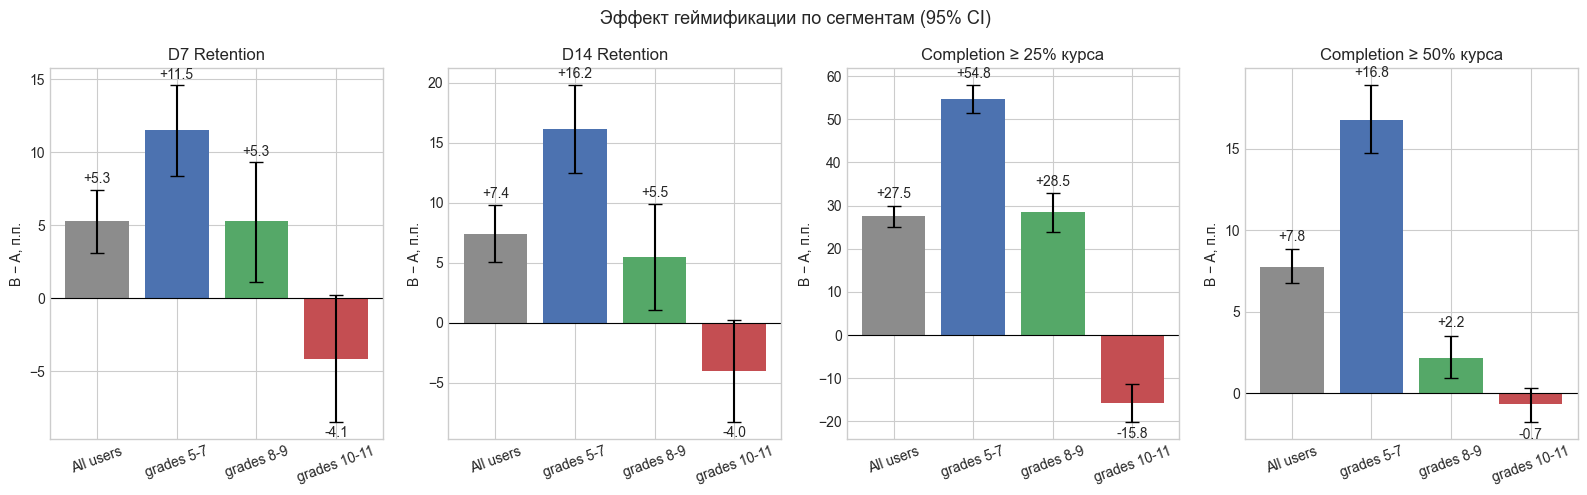

In [34]:
# Все пользователи + три сегмента в одной таблице
plot_df = pd.concat([
    results_df.assign(segment='All users'),
    seg_df
], ignore_index=True)

seg_order = ['All users', 'grades 5-7', 'grades 8-9', 'grades 10-11']
metrics_plot = [('d7_return', 'D7 Retention'),
                ('d14_return', 'D14 Retention'),
                ('completed_25pct', 'Completion ≥ 25% курса'),
                ('completed_50pct', 'Completion ≥ 50% курса'),]

colors = ['#8C8C8C', '#4C72B0', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (metric, title) in zip(axes, metrics_plot):
    sub = plot_df[plot_df['metric'] == metric].set_index('segment').loc[seg_order]
    diff = sub['diff'] * 100
    lo = diff - sub['ci_low'] * 100
    hi = sub['ci_high'] * 100 - diff

    ax.bar(seg_order, diff, color=colors, yerr=[lo, hi], capsize=5,
           error_kw=dict(lw=1.5, ecolor='black'))
    ax.axhline(0, color='black', linewidth=0.8)
    for i, v in enumerate(diff):
        ax.text(i, v + (hi.iloc[i] if v >= 0 else -lo.iloc[i]) + (1 if v >= 0 else -1) * 0.02 * max(abs(diff)),
                f'{v:+.1f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=10)
    ax.set_title(title)
    ax.set_ylabel('B − A, п.п.')
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('Эффект геймификации по сегментам (95% CI)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, 'binary_effect_by_segment.png'), dpi=150, bbox_inches='tight')
plt.show()

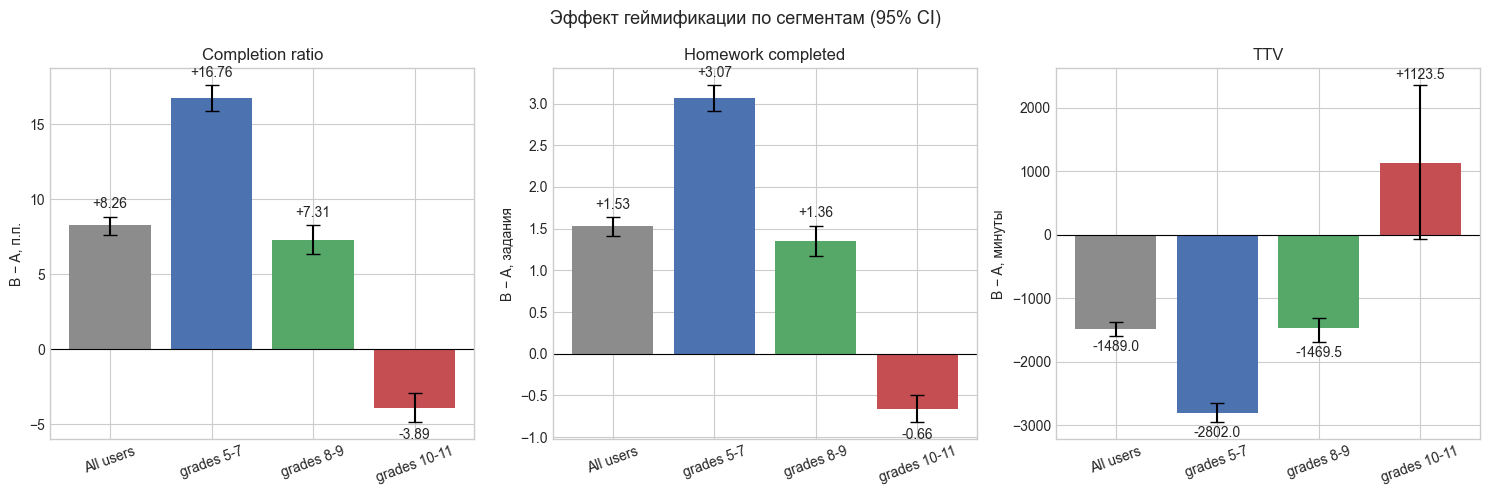

In [35]:
# Все пользователи + три сегмента в одной таблице
plot_df = pd.concat([
    results_df.assign(segment='All users'),
    seg_df
], ignore_index=True)

seg_order = ['All users', 'grades 5-7', 'grades 8-9', 'grades 10-11']

metrics_plot = [('completion_ratio', 'Completion ratio', 100, 'B − A, п.п.'),
                ('homework_completed', 'Homework completed', 1, 'B − A, задания'),
                ('ttv_minutes', 'TTV', 1, 'B − A, минуты')]

colors = ['#8C8C8C', '#4C72B0', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (metric, title, scale, ylabel) in zip(axes, metrics_plot):
    sub = (
        plot_df[plot_df['metric'] == metric]
        .set_index('segment')
        .loc[seg_order]
    )

    diff = sub['diff'] * scale
    lo = (sub['diff'] - sub['ci_low']) * scale
    hi = (sub['ci_high'] - sub['diff']) * scale

    ax.bar(
        seg_order,
        diff,
        color=colors,
        yerr=[lo, hi],
        capsize=5,
        error_kw=dict(lw=1.5, ecolor='black')
    )

    ax.axhline(0, color='black', linewidth=0.8)

    # Подписи значений над/под CI
    offset = 0.02 * max(
        abs(diff).max(),
        abs(sub['ci_low'] * scale).max(),
        abs(sub['ci_high'] * scale).max()
    )

    for i, v in enumerate(diff):
        if v >= 0:
            y = v + hi.iloc[i] + offset
            va = 'bottom'
        else:
            y = v - lo.iloc[i] - offset
            va = 'top'
        ax.text(i, y, f'{v:+.2f}' if metric != 'ttv_minutes' else f'{v:+.1f}', ha='center', va=va, fontsize=10)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20)

fig.suptitle(
    'Эффект геймификации по сегментам (95% CI)',
    fontsize=13
)

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_PATH, 'continuous_effect_by_segment.png'),
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## 4. Выводы

### Выводы

**Качество эксперимента.**  
8 пользователей, попавших одновременно в A и B, 12 ботов (более 100 событий), 8 пользователей с group=NaN, исключены. Итоговая выборка: 5 980 пользователей (A — 2 992, B — 2 988). SRM нет (p = 0.959), баланс по классам в норме (p = 0.237).

**Общий эффект.**  
Все метрики растут, различия значимы и превышают MDE: D7 +5.3 п.п., D14 +7.4 п.п. (95% CI [+5.1; +9.8]), Completion ≥25% +27.5 п.п., среднее число завершённых ДЗ +1.53. Среднее значение прячет различия между классами: взаимодействие group × grade значимо (D7: p ≈ 2·10⁻⁷, D14: p ≈ 3·10⁻⁸).

**По сегментам.**  
- **5–7 классы:** сильный рост по всем метрикам. Решение: раскатывать.
- **8–9 классы:** глубина прохождения растёт заметно (Completion ≥25% +28.5 п.п.). Удержание растёт на +5.3 п.п. (D7) и +5.5 п.п. (D14), но эти эффекты ниже MDE сегмента (6.7 и 7.4 п.п.), а после поправки Холма на 12 тестов p ≈ 0.08. Вывод "положительный эффект на удержание" для этого сегмента на границе значимости.
- **10–11 классы:** глубина прохождения значимо упала (Completion ≥25% −15.8 п.п., число ДЗ −18%). Удержание ниже в B на 4.1 п.п. (D7) и 4.0 п.п. (D14), но CI включает 0 (p с поправкой ≈ 0.19). Вред по удержанию не доказан, вред по прохождению доказан.

**Механизм и дополнительные метрики.**  
Геймификация заметно ускоряет Time-to-Value: медиана TTV падает примерно вдвое (с ~48 ч до ~23.5 ч), в 5–7 классах — с ~47 часов до ~40 минут.  
Доля пользователей, прошедших ≥50% курса, растёт с 0.7% до 8.4% (+7.8 п.п.).  
Относительный прирост: D14 +26%, среднее число завершённых ДЗ +43%, Completion ≥25% +88%.

**Решение.**  
Не раскатывать механику на 100% аудитории. Раскатывать на 5–7 классы. Для 8–9 классов нужны данные: по глубине прохождения эффект сильный, а эффект на удержание стоит подтвердить на большей выборке, раскатку можно вести с мониторингом удержания. Для 10–11 классов оставить старый интерфейс или геймификацию адаптировать.

**Ограничения.**  
- Число ДЗ в курсе неизвестно и оценено по данным, поэтому пороги Completion ≥25% / ≥50% и доля пройденного курса зависят от этого допущения. "Полное" прохождение в данных не наблюдается.
- Разбиение на сегменты 5–7 / 8–9 / 10–11 выбрано после просмотра результатов по классам, поэтому сегментный анализ постфактум.